# **Machine Learning for _A Comparative Analysis of Content Across Major Streaming Services_**

#### **Authors**: Karis Park and Elise Huhn

### **Research Questions:**

1. Are there significant differences in genre distribution across streaming platforms?
2. Is there a difference between the platforms in their balance between movies and television shows?
3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?

### **Brief Project Overview**

Our first two research questions--"Are there significant differences in genre distribution across streaming platforms?" and "Is there a difference between the platforms in their balance between movies and television shows?"--were able to be be answered through our data analysis. However, our third reseach question--"Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?"--should be explored more thoroughly through machine learning models. Since the variable that we are interested in (movie_or_serie) is a categorical variable with known labels, we will be exploring classification models to predict "movie" or "series" given an observations known attributes. 

* talk about overview of splitting data into training, test, and validation split 

* indicate what machine learning models we will be using and which hyperparameters we will tune using the validation set

### **Machine Learning Package Imports**

In [1]:
# Standard imports -- add others as needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

## **Part 1: Preprocessing Data**

In [2]:
#Read in the dataset
streaming_full = pd.read_csv("Data/streaming_combines.csv")
#streaming_full.columns
streaming_full = streaming_full.drop(columns=['title', 'duration_seconds'])
streaming_full.columns

Index(['movie_or_serie', 'release_year', 'channel_streaming', 'action',
       'comedy', 'adventure', 'animation', 'anime', 'drama', 'international',
       'kids', 'horror'],
      dtype='str')

### **Train, Test, and Validation Split**

In [3]:
#Split data into test and train sets
X = streaming_full.drop(columns=['movie_or_serie'])
y = streaming_full['movie_or_serie']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Split train data into Validation and Train sets data
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("------------Split Shapes for Machines Learning--------------------")
print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:      {X_test.shape}")

print("\n------------Stratifyed Class Balance Per Split--------------------")
print(f"Class balance (train): {(y_train.value_counts() / len(y_train)).round(3)}")
print(f"Class balance (validation):   {(y_val.value_counts() / len(y_val)).round(3)}")
print(f"Class balance (test):   {(y_test.value_counts() / len(y_test)).round(3)}")

------------Split Shapes for Machines Learning--------------------
Train:      (14718, 11)
Validation: (3680, 11)
Test:      (4600, 11)

------------Stratifyed Class Balance Per Split--------------------
Class balance (train): movie_or_serie
Movie      0.717
TV Show    0.283
Name: count, dtype: float64
Class balance (validation):   movie_or_serie
Movie      0.717
TV Show    0.283
Name: count, dtype: float64
Class balance (test):   movie_or_serie
Movie      0.717
TV Show    0.283
Name: count, dtype: float64


### **Preprocessor**

In [4]:

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Numerical pipeline: impute + standardize
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), #numerical values are replaced with median due to skewdness
    ('scaler',  StandardScaler()), #standardize values for the logistic regression classifier
])

# Categorical pipeline: impute + one-hot encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), #categorical values replaced with most frequent due to unknown distributions
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)), #one hot encode categorical vars for ml models
])

# Combine the numerical and categorical pipleines into a preprecessor for whole dataset
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,  numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

/var/folders/fw/nls6s5vj1sv6xwslv239h5k40000gn/T/ipykernel_17942/1308005580.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include='object').columns.tolist()


### **Choice Justification for Preprocessing and Pipeline**

## **Part 2: Classification Analysis**

### **Choice Justification for Choosing Classification**

We chose classification as the appropriate analytical approach because our target variable movie_or_serie is a categorical variable with known labels (either "movie" or "tv show"). Every row in our dataset comes pre-labeled with the correct class, making supervised learning applicable. Additionally, we're not trying to discover unknown groupings as we would with clustering, but rather we want to learn a decision boundary that can accurately predict the content type from attributes which is why we chose classification instead of clustering.

### **Classification Model Implmentation**

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42)
}

print(f"{'Model':<30} {'AUC mean':>10} {'AUC std':>9} {'Acc mean':>10} {'Acc std':>9}")
print('-' * 73)

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', clf)])
    auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    acc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:<30} {auc.mean():>10.3f} {auc.std():>9.3f} {acc.mean():>10.3f} {acc.std():>9.3f}")

Model                            AUC mean   AUC std   Acc mean   Acc std
-------------------------------------------------------------------------
Logistic Regression                 0.754     0.014      0.752     0.008
Random Forest                       0.775     0.013      0.770     0.008
SVM                                 0.699     0.017      0.769     0.008


### **Optimizing Hyperparameters (Via GridSearch)**

In [6]:
#GridSearch for best parameters for the SVM model 
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))])

param_grid = {'clf__C': [0.01, 0.1, 1, 10, 100], 
    'clf__gamma': ['scale', 'auto', 0.01, 0.1]}

grid = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='roc_auc_ovr', n_jobs=-1)


grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV AUC:     {grid.best_score_:.3f}")

Best parameters: {'clf__C': 100, 'clf__gamma': 0.01}
Best CV AUC:     0.753


In [15]:
#gridSearch for the best hyperparameters for the RF model 
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 200, 500],
    'clf__max_depth': [5, 10, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': [None, 'balanced']
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='roc_auc_ovr', n_jobs=-1)

grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV AUC:     {grid.best_score_:.3f}")

Best parameters: {'clf__class_weight': None, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Best CV AUC:     0.794


In [8]:
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'clf__penalty': ['l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['lbfgs']
}

grid = GridSearchCV(
    logreg_pipe,
    param_grid,
    cv=5,
    scoring='roc_auc_ovr',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV AUC:     {grid.best_score_:.3f}")

/Users/karispark/Desktop/SCHOOL/2. Graduate/2. Winter 2026/3. si 618/si618_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/karispark/Desktop/SCHOOL/2. Graduate/2. Winter 2026/3. si 618/si618_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/karispark/Desktop/SCHOOL/2. Graduate/2. Winter 20

Best parameters: {'clf__C': 100, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV AUC:     0.754


/Users/karispark/Desktop/SCHOOL/2. Graduate/2. Winter 2026/3. si 618/si618_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
#post-optimized hyperparameter models comparison

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=100, solver = 'lbfgs', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, max_features="sqrt", min_samples_leaf = 1, min_samples_split = 10, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=100, gamma=0.01, probability=True, random_state=42)
}

print(f"{'Model':<30} {'AUC mean':>10} {'AUC std':>9} {'Acc mean':>10} {'Acc std':>9}")
print('-' * 73)

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', clf)])
    auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    acc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:<30} {auc.mean():>10.3f} {auc.std():>9.3f} {acc.mean():>10.3f} {acc.std():>9.3f}")


Model                            AUC mean   AUC std   Acc mean   Acc std
-------------------------------------------------------------------------
Logistic Regression                 0.754     0.014      0.752     0.008
Random Forest                       0.794     0.013      0.776     0.005
SVM                                 0.753     0.015      0.770     0.007


### **Choose best model and confusion matrix and auc and accuracy and blah blah blah all that**

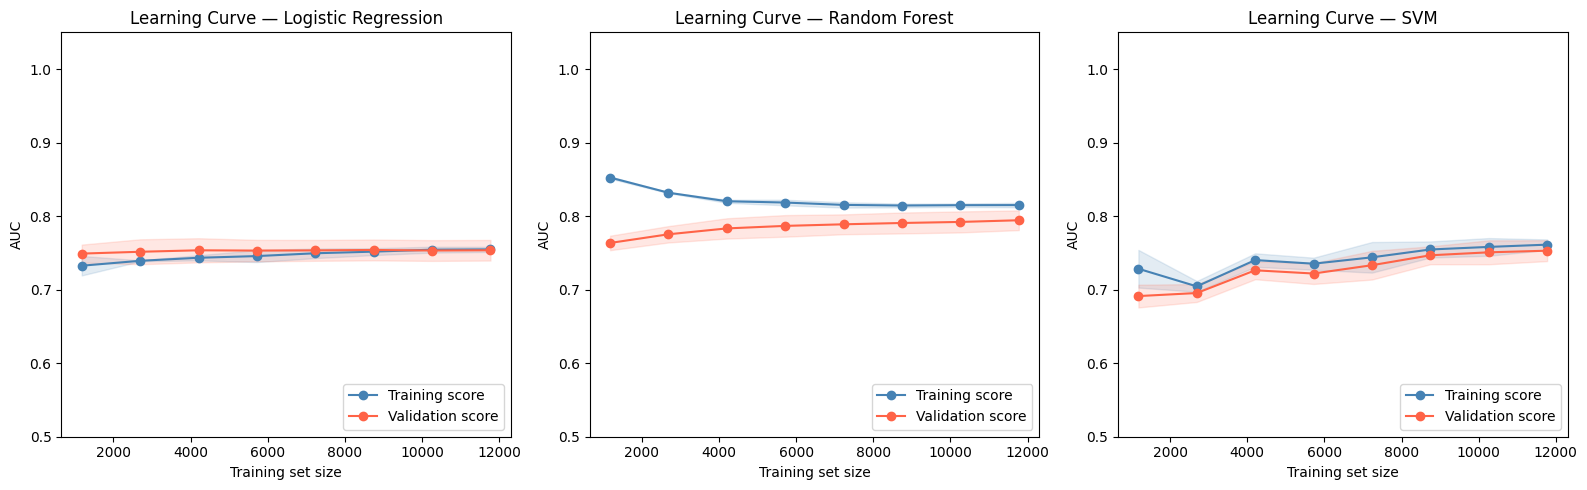

In [10]:
# Learning curves — diagnosing bias and variance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, clf) in zip(axes, [
    ('Logistic Regression', LogisticRegression(max_iter=1000, C=100, solver='lbfgs', random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, max_depth=10, max_features='sqrt', min_samples_leaf=1, min_samples_split=10, random_state=42)),
    ('SVM',                 SVC(kernel='rbf', C=100, gamma=0.01, probability=True, random_state=42))
]):
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', clf)])  # ← use full preprocessor
    sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        cv=5, scoring='roc_auc',
        train_sizes=train_sizes, random_state=42
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(sizes, tm, 'o-', color='steelblue', label='Training score')
    ax.fill_between(sizes, tm - ts, tm + ts, alpha=0.15, color='steelblue')
    ax.plot(sizes, vm, 'o-', color='tomato', label='Validation score')
    ax.fill_between(sizes, vm - vs, vm + vs, alpha=0.15, color='tomato')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('AUC')
    ax.set_title(f'Learning Curve — {name}')
    ax.legend(loc='lower right')
    ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()

In [17]:
# best pipeline
best = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100, max_depth=10, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=10, random_state=42
    ))
])

best.fit(X_train, y_train)

# validation set eval
y_val_pred = best.predict(X_val)
y_val_proba = best.predict_proba(X_val)[:,1]
print("--- Validation Set Performance ---")
print(classification_report(y_val, y_val_pred))
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

# test set eval
y_test_pred = best.predict(X_test)
y_test_proba = best.predict_proba(X_test)[:,1]
print("\n--- Test Set Performance ---")
print(classification_report(y_test, y_test_pred))
print(f"Test AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

--- Validation Set Performance ---
              precision    recall  f1-score   support

       Movie       0.78      0.95      0.86      2637
     TV Show       0.72      0.30      0.42      1043

    accuracy                           0.77      3680
   macro avg       0.75      0.63      0.64      3680
weighted avg       0.76      0.77      0.73      3680

Validation AUC: 0.7793

--- Test Set Performance ---
              precision    recall  f1-score   support

       Movie       0.78      0.96      0.86      3296
     TV Show       0.76      0.31      0.44      1304

    accuracy                           0.78      4600
   macro avg       0.77      0.63      0.65      4600
weighted avg       0.77      0.78      0.74      4600

Test AUC: 0.7832


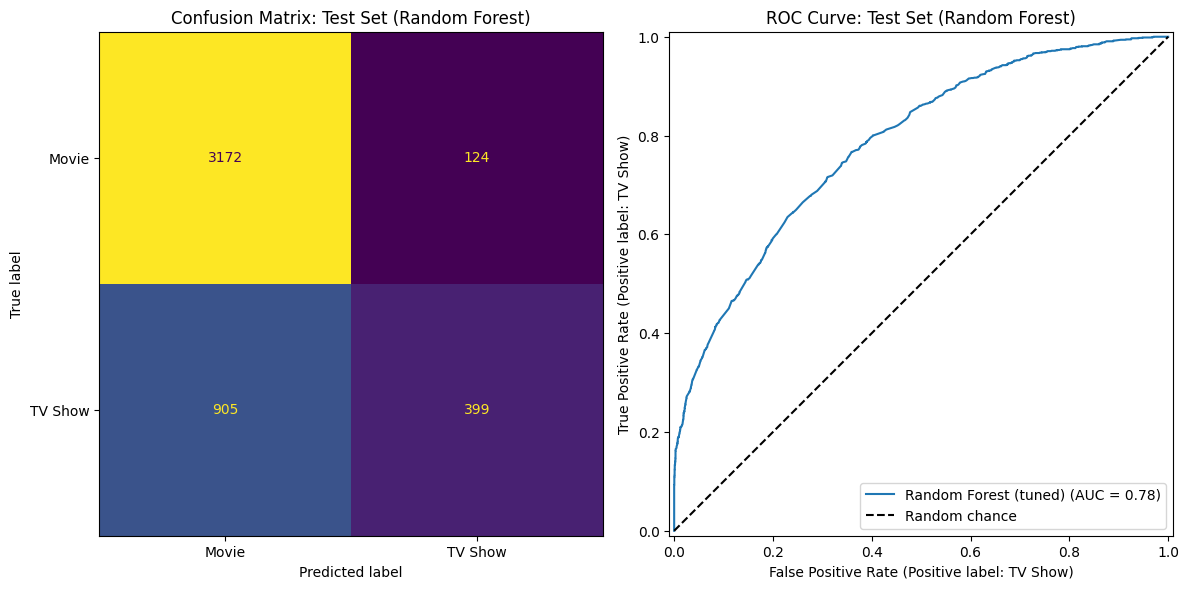

In [18]:
# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

cm = confusion_matrix(y_test, y_test_pred, labels=best.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best.classes_)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix: Test Set (Random Forest)")

# roc curve
RocCurveDisplay.from_predictions(
    y_test, y_test_proba, 
    ax=axes[1], 
    name="Random Forest (tuned)",
    pos_label="TV Show"
)
axes[1].plot([0,1], [0,1], 'k--', label="Random chance")
axes[1].set_title("ROC Curve: Test Set (Random Forest)")
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### **Results**

We compared three classifiers, Logistic Regression, Random Forest, and SVM, using 5-fold cross-validation on the training set, evaluated by both AUC (Area Under the ROC Curve) and accuracy. AUC is our primary metric because the dataset is class-imbalanced (~71.7% Movies, ~28.3% TV Shows), and AUC measures ability independently of the classification threshold. Before tuning the hyperparameters, we got
| Model | AUC Mean | AUC Std | Acc Mean | Acc Std |
|---|---|---|---|---|
| Logistic Regression | 0.754 | 0.014 | 0.752 | 0.008 |
| Random Forest | 0.775 | 0.013 | 0.770 | 0.008 |
| SVM | 0.699 | 0.017 | 0.769 | 0.008 |

Even before tuning the hyperparameters, we can see that random forests is showing better evaluation metrics in comparison to the other two models with the highest AUC and accuracy average score.

Then, we used GridSearchCV with 5-fold cross-validation to tune key hyperparameters for each model. For Logistic Regression, we tuned the regularization strength C (tested values: 0.01, 0.1, 1, 10, 100), which controls the trade-off between fitting the training data and keeping model weights small. A higher C reduces regularization and allows the model to fit more closely to the data. For Random Forest, we tuned n_estimators (number of trees), max_depth (how deep each tree can grow to prevent overfitting), min_samples_split and min_samples_leaf (which control how finely the trees partition the data), max_features (the number of features considered at each split, which adds diversity among trees), and class_weight (to optionally compensate for class imbalance). For SVM, we tuned C (the regularization/margin trade-off) and gamma (which controls how far the influence of a single training example reaches in the RBF kernel). Here, a smaller gamma means smoother, more generalized decision boundaries.

After tuning the hyperparameters, we got 
| Model | AUC Mean | AUC Std | Acc Mean | Acc Std |
|---|---|---|---|---|
| Logistic Regression | 0.754 | 0.014 | 0.752 | 0.008 |
| Random Forest | 0.794 | 0.013 | 0.776 | 0.005 |
| SVM | 0.753 | 0.015 | 0.770 | 0.007 |

Random Forest improved the most, reaching the best AUC average of 0.794 with parameters max_depth=10, max_features=sqrt, min_samples_split=10, and n_estimators=200. Logistic Regression (C=100) and SVM (C=100, gamma=0.01) both achieved average AUC scores near 0.754 which isn't a huge improvement from the results before tuning the hyperparameters. This suggests that the relationship between content attributes and content type is non-linear and not easily captured by a linear or kernel decision boundary, whereas Random Forest's ensemble structure is better suited to leverage the available capacity in the data.

**Best Model: Random Forest**

Random Forest was selected as the best model based on its highest cross-validated AUC (0.794) with the lowest variance across folds (std = 0.013) and the highest accuracy average of 0.776. It was then evaluated on the held-out validation and test sets which data the model never saw during training or tuning. On the validation set, it achieved an AUC of 0.7793 and an overall accuracy of 77%, with a Movie F1-score of 0.86 (precision = 0.78, recall = 0.95) and a TV Show F1-score of 0.42 (precision = 0.72, recall = 0.30). Performance was nearly identical on the test set, with an AUC of 0.7832 and accuracy of 78%, a Movie F1 of 0.86 (precision = 0.78, recall = 0.96), and a TV Show F1 of 0.44 (precision = 0.76, recall = 0.31).

*Validation set performance:*

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Movie | 0.78 | 0.95 | 0.86 | 2,637 |
| TV Show | 0.72 | 0.30 | 0.42 | 1,043 |
| **Weighted avg** | **0.76** | **0.77** | **0.73** | **3,680** |

Validation AUC: **0.7793**

*Test set performance:*

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Movie | 0.78 | 0.96 | 0.86 | 3,296 |
| TV Show | 0.76 | 0.31 | 0.44 | 1,304 |
| **Weighted avg** | **0.77** | **0.78** | **0.74** | **4,600** |

Test AUC: **0.7832**


The model performs very well overall, but the results reveal an important class-imbalance pattern. It classifies Movies with very high recall (0.96) but struggles to identify TV Shows (recall = 0.31), meaning it correctly identifies nearly all Movies while missing about 69% of TV shows, likely defaulting them to the majority class aka Movies. This is most likely caused by the dataset contains roughly 2.5 movies for every TV show, biasing the model toward the majority class, and TV shows and movies likely share many of the same attributes (genre, rating, release year), making them harder to distinguish without format-specific features such as number of episodes or season count. The validation AUC (0.7793) and test AUC (0.7832) being similar confirms that the model generalizes well and is not overfitting. The learning curves further support this because the validation scores plateau and closely track training scores at larger dataset sizes, indicating low variance and that additional training data alone is unlikely to substantially improve performance. Future work could address the class imbalance through oversampling (e.g., SMOTE) and could explore whether additional features or different models might improve recall for TV Shows.